## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp

import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3e' % x)

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc

# from tqdm.notebook import tqdm
from tqdm.notebook import tqdm

beta here denotes exponent in the drag coefficient correction

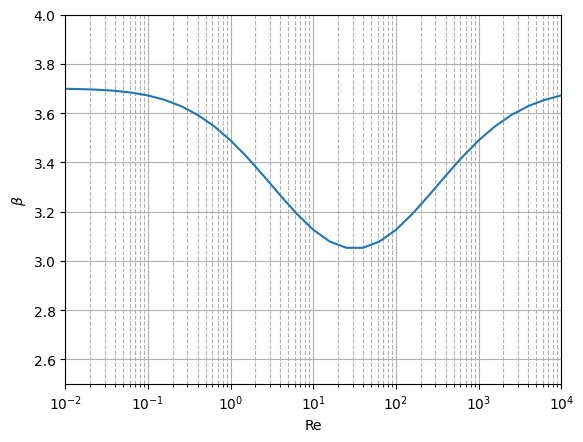

In [2]:
power = np.arange(-2, 5, step=0.2)
Re_vec = 10**power

beta = lambda Re: 3.7 - 0.65*np.exp(
        -0.5 * (1.5 - np.log10(Re))**2
    )

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=beta(Re_vec),
    ax=ax,
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1*10**-2, 10**4)
ax.set_ylim(2.5, 4)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel(r'$\beta$');

Compare with source plot [DiFelice1994VoidageFunction]:

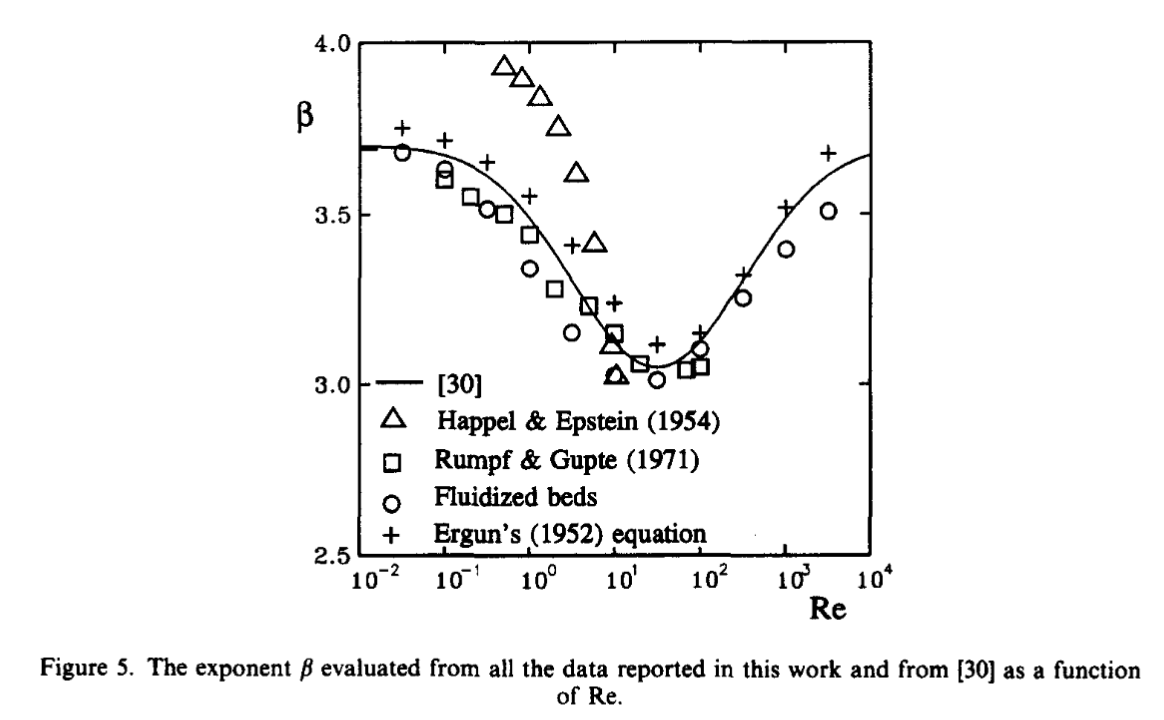

## Drag coefficient plot vs sedimentation drag coefficient plot

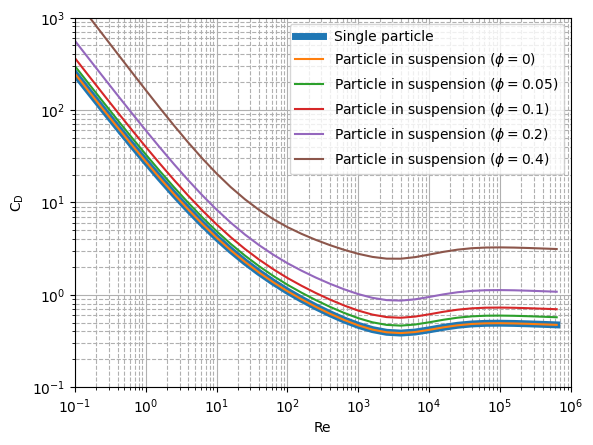

In [3]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power
corrections = True

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
    label='Single particle',
    linewidth=5,
)

phi = 0
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.05
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.10
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.20
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.40
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi, corrections),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$')
ax.legend();

# Test Sedimentation System

Consider Oz oriented down.

## Terminal velocity model

### suspension S17

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 1.8644067796610169,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'base_volume_fraction': 0.1,
 'weight_base_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': 4.548272727272727,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 2.11991341991342}

v_term = 2.806e-05
Re = 5.949e-05


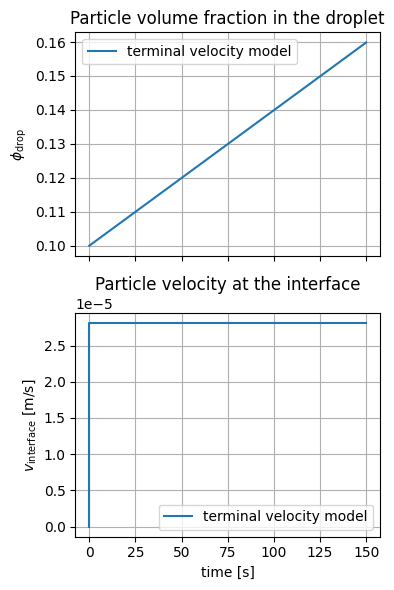

In [6]:
time = np.arange(0, 150.1, 0.1)

d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to base volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "base_volume_fraction": phi0, # initial, base, volume fraction for the system
        "weight_base_volume_fraction": 0.5, # coefficient of the base volume fraction in interface volume fraction estimation
    }
)


phi_drop_term, v_term = system.estimate_drop_volume_fraction(time)

Re = system.get_Re(v_term)[0]
print(f'v_term = {v_term:.3e}')
print(f'Re = {Re:.3e}')


fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)
ax = axes[0]
ax.plot(
    time,
    phi_drop_term,
    label=f'terminal velocity model'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    [0, 0, time[-1]],
    [0, v_term, v_term],
    label=f'terminal velocity model'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
ax.legend()
ax.grid()
fig.tight_layout()

### suspension S15

Init parameters


{'particle_size': 4.15e-05,
 'droplet_size': 0.003,
 'particle_liquid_density_ratio': 0.3813559322033898,
 'density_liquid': 1180,
 'viscosity_liquid': 0.0231,
 'free_fall_acceleration': 9.81,
 'diameter_exit': 0.0016,
 'base_volume_fraction': 0.1,
 'weight_base_volume_fraction': 0.5,
 'height_drop': 0.007031249999999999,
 'buoyancy_acceleration': -15.914000000000001,
 'constant_of_syringe_volume_fraction': 0.05,
 'constant_of_drop_volume_fraction_change_rate': 14.222222222222223,
 'weight_droplet_volume_fraction': 0.5,
 'constant_of_Re': 2.11991341991342}

v_term = -2.008e-05
Re = 4.257e-05
Last phi = 2.431e-02


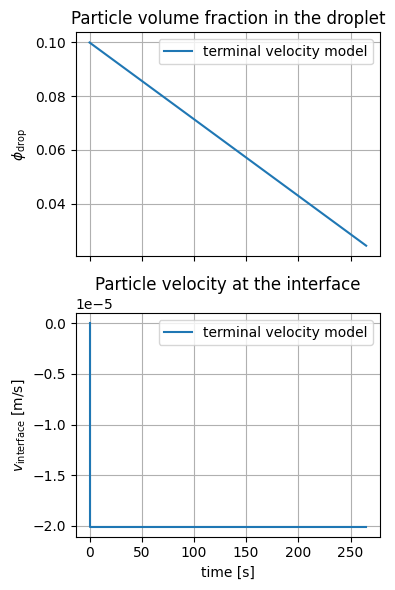

In [8]:
time = np.arange(0, 265.1, 0.1)

d_p = 41.5e-6 # [m]
D_drop = 3e-3 # [m]
D_exit = 1.6e-3 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 450/rho_l
phi_drop = phi0 = 0.10 # assume that initial droplet volume fraction equal to base volume fraction of all syringe
v_interface = 0 # initial particle velocity at the interface [m/s]

g = 9.81 # [m/s^2]

init_state = np.array([v_interface, phi_drop])
# print(init_state.shape)

system = sc.IntegratedSedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "droplet_size": D_drop, # droplet diamter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "diameter_exit": D_exit, # exit diameter of the tip [m]
        "base_volume_fraction": phi0, # initial, base, volume fraction for the system
        "weight_base_volume_fraction": 0.5, # coefficient of the base volume fraction in interface volume fraction estimation
    }
)

phi_drop_term, v_term = system.estimate_drop_volume_fraction(time)

Re = system.get_Re(v_term)[0]
print(f'v_term = {v_term:.3e}')
print(f'Re = {Re:.3e}')
print(f'Last phi = {phi_drop_term[-1]:.3e}')


fig, axes = plt.subplots(2,1, figsize=(4,6), sharex=True)
ax = axes[0]
ax.plot(
    time,
    phi_drop_term,
    label=f'terminal velocity model'
)
# ax.set_xlabel('time [s]')
ax.set_ylabel(r'$\phi_\text{drop}$')
ax.set_title('Particle volume fraction in the droplet')
ax.legend()
ax.grid()

ax = axes[1]
ax.plot(
    [0, 0, time[-1]],
    [0, v_term, v_term],
    label=f'terminal velocity model'
)
ax.set_xlabel('time [s]')
ax.set_ylabel(r'$v_\text{interface}$ [m/s]')
ax.set_title('Particle velocity at the interface')
ax.legend()
ax.grid()
fig.tight_layout()